In [2]:
%load_ext autoreload
%autoreload 2

from src.constants import RAW_DATA_PATH, PROCESSED_DATA_PATH, SAMPLING_RATE, INTERIM_DATA_PATH
from src.utils import group_by_ids

import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
from matplotlib import pyplot as plt
import xarray as xr 
import scipy


custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)

prj = nap.load_folder(PROCESSED_DATA_PATH.parent)
prj.view

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)


📂 ucsf
├── 📂 interim
├── 📂 processed
│   ├── active_wake.npz         |        IntervalSet
│   ├── angle_openfield.npz     |        Tsd
│   ├── hd_spikes_openfield.npz         |        TsdFrame
│   ├── hd_spikes_total.npz     |        TsGroup
│   ├── position_neck.npz       |        TsdFrame
│   ├── sleep.npz       |        IntervalSet
│   ├── spikes_shank_1.npz      |        TsGroup
│   ├── spikes_shank_2.npz      |        TsGroup
│   ├── spikes_shank_3.npz      |        TsGroup
│   └── turn_spikes.npz         |        TsGroup
└── 📂 raw

In [118]:
active_wake     = nap.load_file(PROCESSED_DATA_PATH / "active_wake.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / "hd_spikes_openfield.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / "angle_openfield.npz")

# Convert head direction to radians for polar plotting
hd_angle = np.deg2rad(hd_angle)

In [73]:
spike_times = {}
for neuron_id in range(hd_spikes.shape[1]):
    # Get times where spikes occur (value > 0 or == 1)
    spike_times[neuron_id] = hd_spikes[:, neuron_id].threshold(0.5).index
    
ts_group = nap.TsGroup(spike_times)

C:\Users\iii9781\AppData\Local\Temp\ipykernel_27912\1115201920.py:6: UserWarning: Elements should not be passed as <class 'pynapple.core.time_index.TsIndex'>. Default time units is seconds when creating the Ts object.
  ts_group = nap.TsGroup(spike_times)


In [125]:
tcs = nap.compute_tuning_curves(data = hd_spikes,
                                features = hd_angle,
                                bins = 61,
                                epochs = hd_angle.time_support,
                                range = (0.0, 2 * np.pi),
                                # fs = 20000,
                                feature_names=['head_direction'])
tcs

<xarray.DataArray (unit: 39, head_direction: 61)> Size: 19kB
array([[0.00074293, 0.0001697 , 0.00018336, ..., 0.00621486, 0.0027497 ,
        0.00145328],
       [0.00344795, 0.00337095, 0.002589  , ..., 0.00478572, 0.0043015 ,
        0.00419513],
       [0.00072388, 0.00039341, 0.00021269, ..., 0.00070517, 0.00052634,
        0.00039723],
       ...,
       [0.01085818, 0.00688075, 0.00330043, ..., 0.02390981, 0.02037316,
        0.01530785],
       [0.00431787, 0.00483658, 0.00480395, ..., 0.00451306, 0.0046282 ,
        0.00437921],
       [0.02061149, 0.02017171, 0.01956053, ..., 0.01963181, 0.01985589,
        0.02089813]], shape=(39, 61))
Coordinates:
  * unit            (unit) int64 312B 0 1 2 3 4 5 6 7 ... 32 33 34 35 36 37 38
  * head_direction  (head_direction) float64 488B 0.0515 0.1545 ... 6.129 6.232
Attributes:
    occupancy:  [157485. 129637. 136346. 112828. 106705.  79070.  64427.  572...
    bin_edges:  [array([0.        , 0.10300304, 0.20600608, 0.30900911, 0.412...
    fs:         1000.0

In [126]:
pref_ang = tcs.idxmax(dim="head_direction")

In [127]:
# Normalizes data into the range [0,1]
norm = plt.Normalize()
# Assigns a color in the HSV colormap for each value of preferred angle
color = plt.cm.hsv(norm([i / (2 * np.pi) for i in pref_ang.values]))
color = xr.DataArray(
    color, 
    dims=("unit", "color"),
    coords={"unit": pref_ang.unit}
)

In [128]:
tcs.values = scipy.ndimage.gaussian_filter1d(
    tcs.values, 
    sigma=3, 
    axis=1, 
    mode="wrap" # important for circular variables!
)

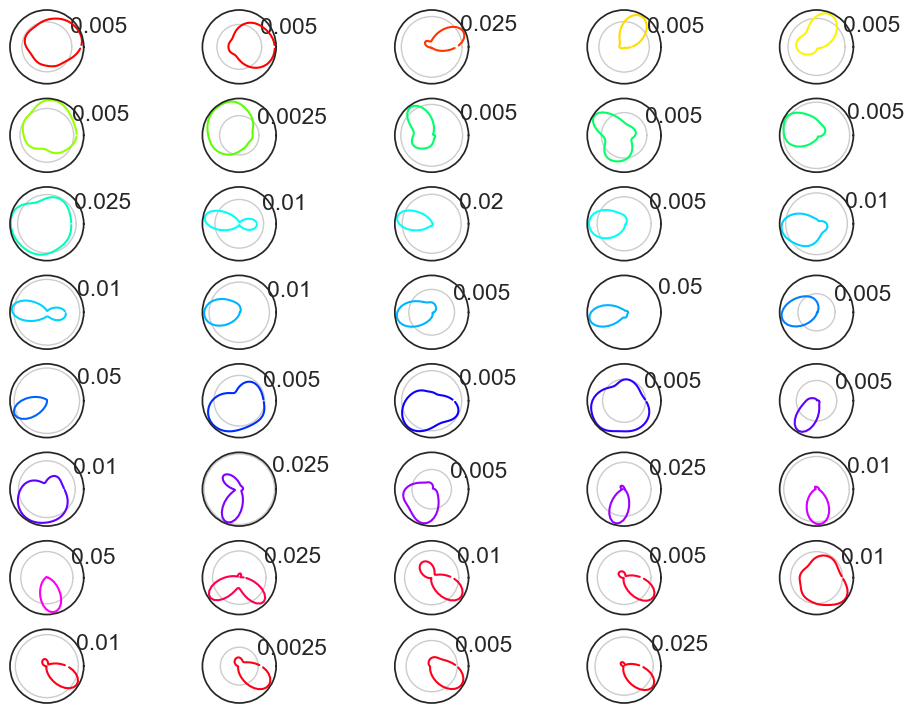

In [130]:
sorted_tuning_curves = tcs.sortby(pref_ang)
plt.figure(figsize=(12, 9))
for i, n in enumerate(sorted_tuning_curves.coords["unit"]):
    # Plot the curves in 8 rows and 4 columns
    plt.subplot(8, 5, i + 1, projection='polar')
    plt.plot(
        sorted_tuning_curves.coords["head_direction"], 
        sorted_tuning_curves.sel(unit=n).values,
        color=color.sel(unit=n).values
    )  # Colour of the curves determined by preferred angle    
    plt.xticks([])
plt.show()

Estimated Concentration (Kappa): 0.3005


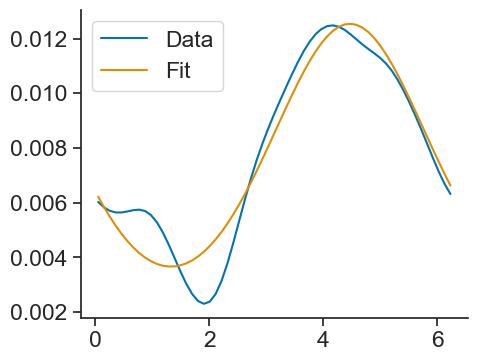

In [172]:
from scipy.optimize import curve_fit

def von_mises_tuning(x, kappa, loc, amp, offset):
    return amp * np.exp(kappa * np.cos(x - loc)) + offset

# Get data for the specific unit (using isel for positional indexing)
# Corresponds to sorted_tuning_curves[3, :]
tc_data = sorted_tuning_curves.isel(unit=25)
x_data = tc_data.coords["head_direction"].values
y_data = tc_data.values

# Initial parameter guesses to help convergence
p0 = [
    1.0,                            # kappa (concentration)
    x_data[np.argmax(y_data)],      # loc (angle of peak)
    np.max(y_data) - np.min(y_data),# amp (amplitude)
    np.min(y_data)                  # offset (baseline)
]

# Fit the curve
popt, pcov = curve_fit(von_mises_tuning, x_data, y_data, p0=p0)
kappa_fit, loc_fit, amp_fit, offset_fit = popt

print(f"Estimated Concentration (Kappa): {kappa_fit:.4f}")

# Optional: Visualize the fit
plt.figure(figsize=(5,4))
plt.plot(x_data, y_data, label='Data')
plt.plot(x_data, von_mises_tuning(x_data, *popt), label='Fit')
plt.legend()
plt.show()

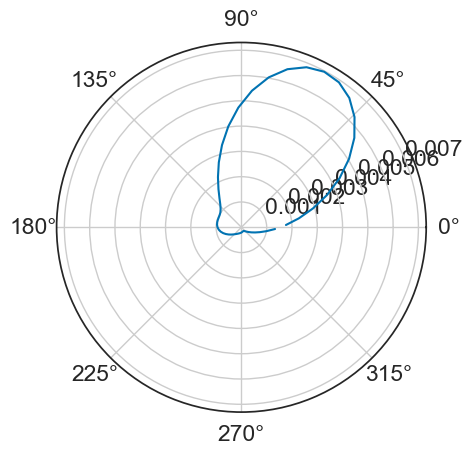

In [149]:
fig, ax = plt.subplots(subplot_kw=dict(projection='polar'))
ax.plot(sorted_tuning_curves.coords["head_direction"], sorted_tuning_curves[3, :])

In [171]:
sorted_tuning_curves['unit']

<xarray.DataArray 'unit' (unit: 39)> Size: 312B
array([14, 30, 10, 26, 25, 19, 17,  2, 11, 20, 38,  7, 12, 24,  4,  6, 22, 23,
       29, 21,  8, 37,  1, 15,  5, 16,  9,  3, 13, 27, 28,  0, 32, 33, 18, 31,
       34, 35, 36])
Coordinates:
  * unit     (unit) int64 312B 14 30 10 26 25 19 17 2 ... 0 32 33 18 31 34 35 36

In [173]:
kappa_values = {}

# Iterate over all units
for n in sorted_tuning_curves.coords["unit"].values:
    # Get tuning curve data
    tc_data = sorted_tuning_curves.sel(unit=n)
    x_data = tc_data.coords["head_direction"].values
    y_data = tc_data.values

    # Check for NaNs or Infinite values
    if not np.isfinite(y_data).all():
        print(f"Skipping Unit {n}: Contains NaN or Inf values")
        kappa_values[n] = np.nan
        continue

    # Initial parameter guesses: [kappa, loc (peak angle), amp (range), offset (min)]
    p0 = [
        1.0,  
        x_data[np.argmax(y_data)],
        np.max(y_data) - np.min(y_data) + 1e-6, # +1e-6 prevents amp=0 issues
        np.min(y_data)
    ]
    
    try:
        # Fit with Bounds and increased Max Evaluations
        # Bounds: kappa [0, 700], loc [-inf, inf], amp [0, inf], offset [0, inf]
        # kappa=700 is chosen to prevent np.exp(kappa) overflow
        popt, _ = curve_fit(
            von_mises_tuning, 
            x_data, y_data, 
            p0=p0,
            bounds=([0, -np.inf, 0, 0], [700, np.inf, np.inf, np.inf]),
            maxfev=10000 
        )
        
        kappa, loc, amp, offset = popt
        kappa_values[n] = kappa

        # Create polar plot
        fig, ax = plt.subplots(subplot_kw=dict(projection='polar'), figsize=(5, 5))
        ax.plot(x_data, y_data, label='Data', linewidth=2)
        ax.plot(x_data, von_mises_tuning(x_data, *popt), label=f'Fit (k={kappa:.2f})', linestyle='--', color='red')
        
        ax.set_title(f"Unit {n} Tuning Fit")
        ax.legend(loc='lower left', bbox_to_anchor=(-0.2, -0.2))
        ax.grid(True)
        
        # Save plot
        plt.savefig(INTERIM_DATA_PATH / f"unit_{n}_tuning_fit.png", bbox_inches='tight')
        plt.close(fig)  # Close figure to free memory

    except RuntimeError:
        print(f"Fit failed for unit {n} (Convergence Error)")
        kappa_values[n] = np.nan
    except Exception as e:
        print(f"Fit failed for unit {n} (Error: {e})")
        kappa_values[n] = np.nan

# Save kappa values to DataFrame and CSV
kappa_df = pd.DataFrame.from_dict(kappa_values, orient='index', columns=['kappa'])
kappa_df.index.name = 'unit_id'
kappa_df.to_csv(INTERIM_DATA_PATH / "tuning_curve_kappa.csv")

print(f"Saved fitted plots and kappa values to {INTERIM_DATA_PATH}")
kappa_df.head()

Saved fitted plots and kappa values to D:\common_datasets\ucsf\interim


,kappa
unit_id,
14,1.201719
30,0.858730
10,4.257572
26,3.147613
25,0.882464


In [4]:
import pandas as pd

kappa_df = pd.read_csv(INTERIM_DATA_PATH / "tuning_curve_kappa.csv", index_col='unit_id')
kappa_df

,kappa
unit_id,
14,1.201719
30,0.858730
10,4.257572
26,3.147613
25,0.882464
19,0.338354
17,0.523155
2,1.028221
11,0.475519


In [6]:
kappa_df

# mua = 0 # unit with multiple tuning peaks
k_threshold = 1.6

to_be_removed = list(kappa_df[kappa_df['kappa'] <= k_threshold].index)
# to_be_removed += [mua]
to_be_removed

[14, 30, 25, 19, 17, 2, 11, 20, 38, 37, 1, 15, 16, 3, 0, 18]